In [10]:
# ============================================================
# HYPERPARAMETER TUNING WITH GRID SEARCH
# SALES DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
# ============================================================
# STEP 2: UPLOAD AND LOAD SALES DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name="Sales_Data")

print("Dataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Saving Sales_Analysis_Dataset.xlsx to Sales_Analysis_Dataset (1).xlsx
Dataset loaded successfully!
File: Sales_Analysis_Dataset (1).xlsx
Shape: (5000, 22)

First 5 rows:


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02



Column names:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21']


In [16]:
# ============================================================
# STEP 6B: RECREATE FEATURES AND TARGET
# ============================================================

features = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Sales",
    "Profit",
    "Profit_Margin"
]

target = "Customer_Segment"

# Keep only rows where the required columns have values
model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Features and target recreated successfully!")

print("\nModel dataset shape:", model_df.shape)
print("X shape:", X.shape)
print("y shape:", y_encoded.shape)

print("\nCustomer Segment classes:")
print(label_encoder.classes_)

Features and target recreated successfully!

Model dataset shape: (5000, 7)
X shape: (5000, 6)
y shape: (5000,)

Customer Segment classes:
['Consumer' 'Corporate' 'Small Business']


In [17]:
# ============================================================
# STEP 6C: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Train-test split completed!")

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Train-test split completed!

Training data:
X_train: (4000, 6)
y_train: (4000,)

Testing data:
X_test: (1000, 6)
y_test: (1000,)


In [18]:
# ============================================================
# STEP 7: FEATURE STANDARDIZATION
# ============================================================

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed!")

print("\nX_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nFirst 5 standardized training rows:")
print(X_train_scaled[:5])

Feature standardization completed!

X_train_scaled shape: (4000, 6)
X_test_scaled shape: (1000, 6)

First 5 standardized training rows:
[[ 1.36590937 -0.7880249  -0.82625763 -0.51939001 -0.16586495  1.21231351]
 [-0.50600069 -0.15610026  0.30521465 -0.30465336 -0.36527835 -1.08726186]
 [ 1.36590937 -0.79745095  2.00242307 -0.5551193  -0.36152507 -0.39800908]
 [ 0.89793186  0.13999156 -0.26052149  0.55752893  0.4328648  -0.55668598]
 [ 0.42995434 -0.8130821  -0.82625763 -0.57647474 -0.29510833  1.6685096 ]]


In [19]:
# ============================================================
# STEP 8: CREATE KNN MODEL
# ============================================================

knn = KNeighborsClassifier()

print("KNN model created successfully!")
print(knn)

KNN model created successfully!
KNeighborsClassifier()


In [20]:
# ============================================================
# STEP 9: DEFINE HYPERPARAMETER GRID
# ============================================================

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

print("Hyperparameter grid created successfully!")

print("\nParameters to test:")
for parameter, values in param_grid.items():
    print(parameter, ":", values)

# Calculate total combinations
total_combinations = (
    len(param_grid["n_neighbors"])
    * len(param_grid["weights"])
    * len(param_grid["metric"])
)

print("\nTotal hyperparameter combinations:", total_combinations)

Hyperparameter grid created successfully!

Parameters to test:
n_neighbors : [3, 5, 7, 9, 11, 15]
weights : ['uniform', 'distance']
metric : ['euclidean', 'manhattan']

Total hyperparameter combinations: 24


In [21]:
# ============================================================
# STEP 10: GRID SEARCH CROSS-VALIDATION
# ============================================================

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search...")
print("Please wait while all combinations are tested...\n")

grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search completed successfully!")

Starting Grid Search...
Please wait while all combinations are tested...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Grid Search completed successfully!


In [22]:
# ============================================================
# STEP 11: DISPLAY BEST HYPERPARAMETERS
# ============================================================

print("Best Hyperparameters:")
print("--------------------------------")

for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest Cross-Validation Accuracy:")
print("--------------------------------")
print(f"{grid_search.best_score_:.4f}")

print(f"\nPercentage: {grid_search.best_score_ * 100:.2f}%")

Best Hyperparameters:
--------------------------------
metric: euclidean
n_neighbors: 15
weights: uniform

Best Cross-Validation Accuracy:
--------------------------------
0.5437

Percentage: 54.37%


In [23]:
# ============================================================
# STEP 12: EVALUATE BEST MODEL
# ============================================================

# Get the best model
best_knn = grid_search.best_estimator_

# Make predictions
y_pred = best_knn.predict(X_test_scaled)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Best KNN Model Evaluation")
print("=" * 40)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print("=" * 40)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Best KNN Model Evaluation
Test Accuracy: 0.5390
Test Accuracy: 53.90%

Classification Report:
                precision    recall  f1-score   support

      Consumer       0.57      0.91      0.70       573
     Corporate       0.22      0.06      0.10       280
Small Business       0.25      0.01      0.01       147

      accuracy                           0.54      1000
     macro avg       0.35      0.33      0.27      1000
  weighted avg       0.42      0.54      0.43      1000



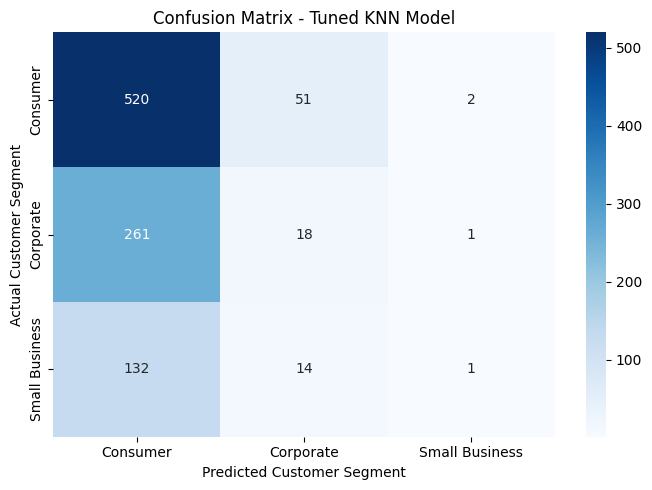

In [24]:
# ============================================================
# STEP 13: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Tuned KNN Model")
plt.xlabel("Predicted Customer Segment")
plt.ylabel("Actual Customer Segment")
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# STEP 14: COMPARE DEFAULT AND TUNED KNN
# ============================================================

# Create default KNN
default_knn = KNeighborsClassifier()

# Train default KNN
default_knn.fit(X_train_scaled, y_train)

# Predict using default KNN
default_pred = default_knn.predict(X_test_scaled)

# Calculate default accuracy
default_accuracy = accuracy_score(y_test, default_pred)

# Tuned model accuracy
tuned_accuracy = accuracy_score(y_test, y_pred)

print("KNN Model Comparison")
print("=" * 45)

print(f"Default KNN Accuracy : {default_accuracy * 100:.2f}%")
print(f"Tuned KNN Accuracy   : {tuned_accuracy * 100:.2f}%")

print("\nImprovement:")
improvement = tuned_accuracy - default_accuracy
print(f"{improvement * 100:.2f} percentage points")

KNN Model Comparison
Default KNN Accuracy : 51.70%
Tuned KNN Accuracy   : 53.90%

Improvement:
2.20 percentage points


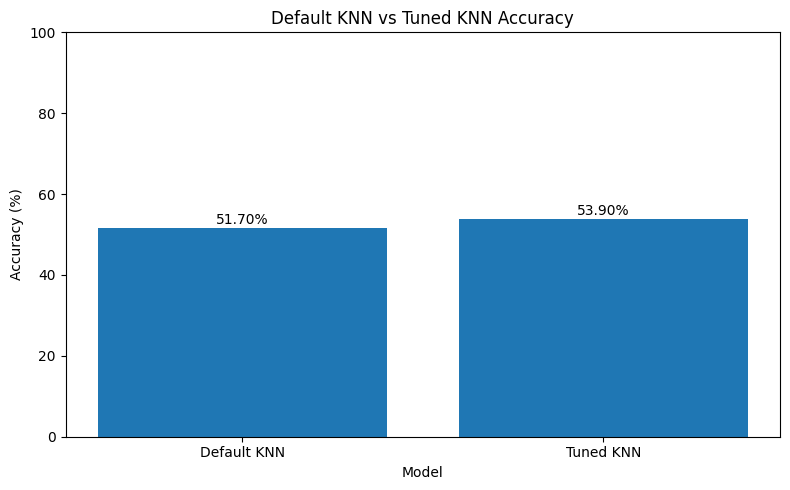

In [26]:
# ============================================================
# STEP 15: ACCURACY COMPARISON VISUALIZATION
# ============================================================

models = ["Default KNN", "Tuned KNN"]
accuracies = [default_accuracy * 100, tuned_accuracy * 100]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies)

plt.title("Default KNN vs Tuned KNN Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# Display values above bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# STEP 16: GRID SEARCH RESULTS
# ============================================================

results = pd.DataFrame(grid_search.cv_results_)

# Select useful columns
results_summary = results[
    [
        "param_n_neighbors",
        "param_weights",
        "param_metric",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

# Rename columns
results_summary.columns = [
    "n_neighbors",
    "weights",
    "metric",
    "mean_cv_accuracy",
    "std_cv_accuracy",
    "rank"
]

# Sort by performance
results_summary = results_summary.sort_values(
    by="mean_cv_accuracy",
    ascending=False
)

print("Top 10 Grid Search Results")
print("=" * 70)

display(results_summary.head(10))

Top 10 Grid Search Results


,n_neighbors,weights,metric,mean_cv_accuracy,std_cv_accuracy,rank
10,15,uniform,euclidean,0.54375,0.007500,1
22,15,uniform,manhattan,0.54150,0.007391,2
20,11,uniform,manhattan,0.53900,0.003984,3
8,11,uniform,euclidean,0.53500,0.006124,4
6,9,uniform,euclidean,0.52475,0.004770,5
18,9,uniform,manhattan,0.52200,0.006643,6
16,7,uniform,manhattan,0.51375,0.009083,7
4,7,uniform,euclidean,0.51300,0.007483,8
2,5,uniform,euclidean,0.51000,0.005755,9
14,5,uniform,manhattan,0.50600,0.003482,10


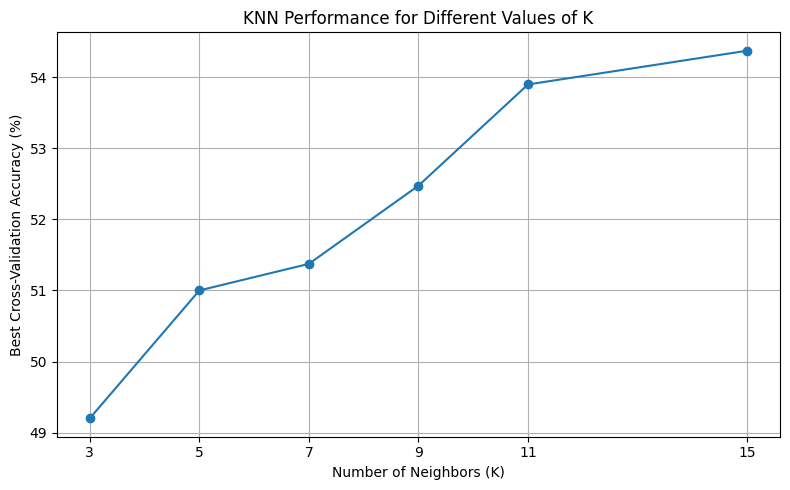

In [28]:
# ============================================================
# STEP 17: VISUALIZE GRID SEARCH PERFORMANCE
# ============================================================

# Group results by number of neighbors
k_performance = (
    results_summary
    .groupby("n_neighbors")["mean_cv_accuracy"]
    .max()
    .reset_index()
)

# Convert k values to integers
k_performance["n_neighbors"] = k_performance["n_neighbors"].astype(int)

plt.figure(figsize=(8, 5))

plt.plot(
    k_performance["n_neighbors"],
    k_performance["mean_cv_accuracy"] * 100,
    marker="o"
)

plt.title("KNN Performance for Different Values of K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Best Cross-Validation Accuracy (%)")
plt.xticks(k_performance["n_neighbors"])
plt.grid(True)
plt.tight_layout()

plt.show()

In [29]:
# ============================================================
# STEP 18: SAVE BEST MODEL
# ============================================================

import joblib

# Save the tuned KNN model
joblib.dump(best_knn, "best_knn_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save the label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("Best KNN model saved successfully!")
print("File: best_knn_model.pkl")

print("\nScaler saved successfully!")
print("File: scaler.pkl")

print("\nLabel encoder saved successfully!")
print("File: label_encoder.pkl")

Best KNN model saved successfully!
File: best_knn_model.pkl

Scaler saved successfully!
File: scaler.pkl

Label encoder saved successfully!
File: label_encoder.pkl


In [30]:
# ============================================================
# STEP 19: LOAD AND TEST SAVED MODEL
# ============================================================

# Load saved files
loaded_model = joblib.load("best_knn_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

# Transform test data using the loaded scaler
X_test_loaded = loaded_scaler.transform(X_test)

# Make predictions
loaded_predictions = loaded_model.predict(X_test_loaded)

# Calculate accuracy
loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("Saved model loaded successfully!")
print("=" * 45)
print(f"Loaded Model Accuracy: {loaded_accuracy * 100:.2f}%")

# Verify against the original tuned model
print("\nOriginal Tuned Model Accuracy:")
print(f"{tuned_accuracy * 100:.2f}%")

if abs(loaded_accuracy - tuned_accuracy) < 0.0001:
    print("\nModel verification: SUCCESS")
else:
    print("\nModel verification: Accuracy differs")

Saved model loaded successfully!
Loaded Model Accuracy: 53.90%

Original Tuned Model Accuracy:
53.90%

Model verification: SUCCESS


In [31]:
# ============================================================
# STEP 20: FINAL RESULTS SUMMARY
# ============================================================

print("=" * 60)
print("HYPERPARAMETER TUNING WITH GRID SEARCH")
print("=" * 60)

print("\nDataset Information")
print("-" * 60)
print(f"Total usable records : {len(X)}")
print(f"Number of features   : {len(features)}")
print(f"Training records     : {len(X_train)}")
print(f"Testing records      : {len(X_test)}")

print("\nModel Information")
print("-" * 60)
print("Algorithm            : K-Nearest Neighbors (KNN)")
print("Optimization method  : Grid Search with 5-Fold Cross-Validation")
print(f"Combinations tested  : {total_combinations}")

print("\nBest Hyperparameters")
print("-" * 60)
for parameter, value in grid_search.best_params_.items():
    print(f"{parameter:20}: {value}")

print("\nPerformance")
print("-" * 60)
print(f"Best CV Accuracy     : {grid_search.best_score_ * 100:.2f}%")
print(f"Default KNN Accuracy : {default_accuracy * 100:.2f}%")
print(f"Tuned KNN Accuracy   : {tuned_accuracy * 100:.2f}%")
print(f"Improvement          : {(tuned_accuracy - default_accuracy) * 100:.2f}%")

print("\nModel Files")
print("-" * 60)
print("best_knn_model.pkl")
print("scaler.pkl")
print("label_encoder.pkl")

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

HYPERPARAMETER TUNING WITH GRID SEARCH

Dataset Information
------------------------------------------------------------
Total usable records : 5000
Number of features   : 6
Training records     : 4000
Testing records      : 1000

Model Information
------------------------------------------------------------
Algorithm            : K-Nearest Neighbors (KNN)
Optimization method  : Grid Search with 5-Fold Cross-Validation
Combinations tested  : 24

Best Hyperparameters
------------------------------------------------------------
metric              : euclidean
n_neighbors         : 15
weights             : uniform

Performance
------------------------------------------------------------
Best CV Accuracy     : 54.37%
Default KNN Accuracy : 51.70%
Tuned KNN Accuracy   : 53.90%
Improvement          : 2.20%

Model Files
------------------------------------------------------------
best_knn_model.pkl
scaler.pkl
label_encoder.pkl

PROJECT COMPLETED SUCCESSFULLY!


In [32]:
# ============================================================
# STEP 21: TEST WITH A NEW CUSTOMER RECORD
# ============================================================

# Example new customer data
new_customer = pd.DataFrame({
    "Quantity": [5],
    "Unit_Price": [1000],
    "Discount": [0.10],
    "Sales": [4500],
    "Profit": [900],
    "Profit_Margin": [20]
})

# Scale the new data
new_customer_scaled = loaded_scaler.transform(new_customer)

# Predict customer segment
prediction = loaded_model.predict(new_customer_scaled)

# Convert numerical prediction back to original class name
predicted_segment = loaded_encoder.inverse_transform(prediction)

print("=" * 50)
print("NEW CUSTOMER PREDICTION")
print("=" * 50)

print("\nInput Data:")
display(new_customer)

print("Predicted Customer Segment:")
print(predicted_segment[0])

NEW CUSTOMER PREDICTION

Input Data:


,Quantity,Unit_Price,Discount,Sales,Profit,Profit_Margin
0,5,1000,0.1,4500,900,20


Predicted Customer Segment:
Consumer


In [33]:
# ============================================================
# STEP 22: MODEL PERFORMANCE REPORT
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

performance_report = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        test_accuracy,
        precision,
        recall,
        f1
    ]
})

performance_report["Percentage"] = (
    performance_report["Score"] * 100
).round(2)

print("Tuned KNN Model Performance")
print("=" * 50)

display(performance_report)

Tuned KNN Model Performance


,Metric,Score,Percentage
0,Accuracy,0.539000,53.90
1,Precision,0.423826,42.38
2,Recall,0.539000,53.90
3,F1-Score,0.430738,43.07


In [34]:
# ============================================================
# STEP 23: DOWNLOAD MODEL FILES
# ============================================================

from google.colab import files

print("Downloading trained model files...")

files.download("best_knn_model.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

print("\nDownload process started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download process started!


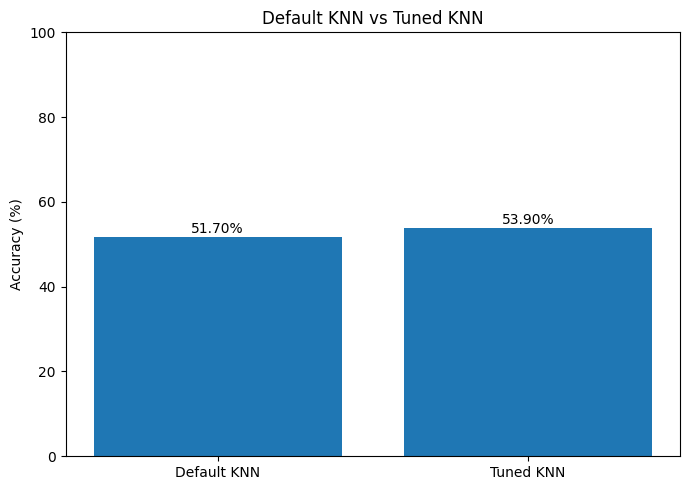

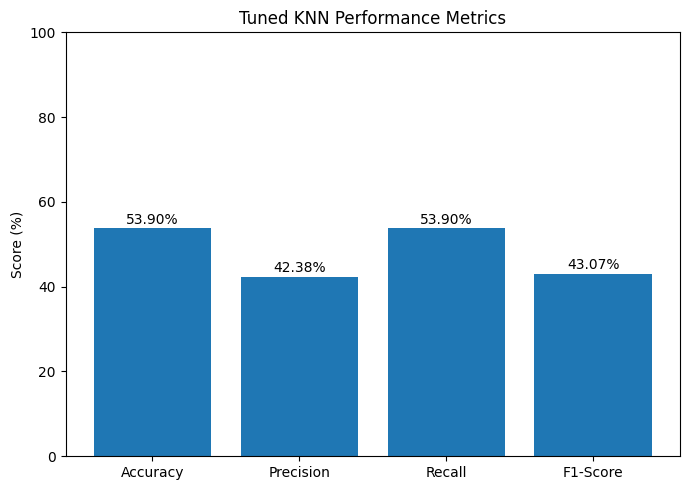

BEST HYPERPARAMETERS FOUND BY GRID SEARCH
metric              : euclidean
n_neighbors         : 15
weights             : uniform

Best Cross-Validation Accuracy:
54.37%


In [35]:
# ============================================================
# STEP 24: FINAL RESULTS VISUALIZATION
# ============================================================

# -------------------------------
# 1. Accuracy Comparison
# -------------------------------

plt.figure(figsize=(7, 5))

models = ["Default KNN", "Tuned KNN"]
accuracy_values = [
    default_accuracy * 100,
    tuned_accuracy * 100
]

bars = plt.bar(models, accuracy_values)

plt.title("Default KNN vs Tuned KNN")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# -------------------------------
# 2. Performance Metrics
# -------------------------------

plt.figure(figsize=(7, 5))

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values = [
    test_accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100
]

bars = plt.bar(metrics, metric_values)

plt.title("Tuned KNN Performance Metrics")
plt.ylabel("Score (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# -------------------------------
# 3. Best Hyperparameters
# -------------------------------

print("=" * 55)
print("BEST HYPERPARAMETERS FOUND BY GRID SEARCH")
print("=" * 55)

for parameter, value in grid_search.best_params_.items():
    print(f"{parameter:20}: {value}")

print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_ * 100:.2f}%")

In [36]:
# ============================================================
# STEP 25: SAVE GRID SEARCH RESULTS
# ============================================================

# Save all Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results.to_csv(
    "grid_search_results.csv",
    index=False
)

print("Grid Search results saved successfully!")
print("File: grid_search_results.csv")

print("\nTotal combinations tested:", len(grid_results))

print("\nBest 5 configurations:")
display(
    results_summary.head(5)
)

Grid Search results saved successfully!
File: grid_search_results.csv

Total combinations tested: 24

Best 5 configurations:


,n_neighbors,weights,metric,mean_cv_accuracy,std_cv_accuracy,rank
10,15,uniform,euclidean,0.54375,0.007500,1
22,15,uniform,manhattan,0.54150,0.007391,2
20,11,uniform,manhattan,0.53900,0.003984,3
8,11,uniform,euclidean,0.53500,0.006124,4
6,9,uniform,euclidean,0.52475,0.004770,5


In [37]:
# ============================================================
# STEP 26: DOWNLOAD GRID SEARCH RESULTS
# ============================================================

from google.colab import files

files.download("grid_search_results.csv")

print("Grid Search results download started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Grid Search results download started!


In [38]:
# ============================================================
# STEP 28: CREATE REQUIREMENTS.TXT
# ============================================================

requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
openpyxl
joblib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully!")

print("\nContents:")
print(requirements)

requirements.txt created successfully!

Contents:
pandas
numpy
matplotlib
seaborn
scikit-learn
openpyxl
joblib



In [39]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# ============================================================
# STEP 3: CHECK AND CLEAN DATA
# ============================================================

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

print("\nData cleaning completed!")
print("Updated shape:", df.shape)

Missing values:
Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Product_Name        0
Category            0
Sub_Category        0
Region              0
City                0
Quantity            0
Unit_Price          0
Discount            0
Sales               0
Profit              0
Payment_Method      0
Year                0
Month               0
Month_Number        0
Quarter             0
Profit_Margin       0
Unnamed: 20         0
Unnamed: 21         0
dtype: int64

Duplicate rows: 0

Data cleaning completed!
Updated shape: (0, 22)


In [12]:
# ============================================================
# STEP 4: FEATURE SELECTION
# ============================================================

features = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Sales",
    "Profit",
    "Profit_Margin"
]

target = "Customer_Segment"

# Create X and y
X = df[features]
y = df[target]

print("Features selected:")
print(features)

print("\nTarget variable:", target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

print("\nSample of X:")
display(X.head())

print("\nSample of y:")
display(y.head())

Features selected:
['Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Profit_Margin']

Target variable: Customer_Segment

X shape: (0, 6)
y shape: (0,)

Target classes:
[]

Sample of X:


,Quantity,Unit_Price,Discount,Sales,Profit,Profit_Margin



Sample of y:


,Customer_Segment


In [13]:
# ============================================================
# STEP 5: ENCODE TARGET VARIABLE
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Target encoding completed!")

print("\nOriginal classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
for class_name, class_number in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(class_name, "->", class_number)

print("\nFirst 10 encoded values:")
print(y_encoded[:10])

Target encoding completed!

Original classes:
[]

Encoded classes:

First 10 encoded values:
[]


In [14]:
# ============================================================
# STEP 6A: RESTORE DATASET AFTER EMPTY DATAFRAME
# ============================================================

# Reload the original Sales_Data sheet
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name="Sales_Data")

# Remove only completely empty rows
df = df.dropna(how="all")

print("Dataset restored successfully!")
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset restored successfully!
Shape: (5000, 22)

Missing values:
Order_ID               0
Order_Date             0
Customer_Name          0
Customer_Segment       0
Product_Name           0
Category               0
Sub_Category           0
Region                 0
City                   0
Quantity               0
Unit_Price             0
Discount               0
Sales                  0
Profit                 0
Payment_Method         0
Year                   0
Month                  0
Month_Number           0
Quarter                0
Profit_Margin          0
Unnamed: 20         4999
Unnamed: 21         4994
dtype: int64
